# 03 — Solar Normalization

## Objective

This notebook converts observed solar irradiance into a normalized measure of solar availability relative to clear-sky conditions.

The primary normalized metric is the Clear-Sky Index (CSI):

$$
CSI_t = \frac{GHI_{\text{observed},t}}{GHI_{\text{clear},t}}
$$

where:

- $GHI_{\text{observed},t}$ is the all-sky global horizontal irradiation from CAMS.
- $GHI_{\text{clear},t}$ is the corresponding CAMS clear-sky global horizontal irradiation.

## Scientific Motivation

Raw GHI varies strongly with the solar cycle and therefore cannot be used directly to identify anomalously low solar availability.

Normalization against clear-sky conditions accounts for the expected variation associated with solar position and provides a relative measure of solar availability under the prevailing atmospheric conditions.

## Important Distinction

The CSI calculated in this notebook is a normalized solar-availability measure. It is **not itself a drought classification**.

Drought identification will be performed later using the historical distribution of normalized solar availability together with explicitly defined persistence criteria.

## Nighttime and Near-Zero Solar Periods

Nighttime observations are excluded from CSI calculation because the clear-sky reference is zero during these periods, making the ratio undefined.

Observations with very small but positive clear-sky irradiation require additional inspection because the ratio can become sensitive when the denominator approaches zero.

Therefore, the treatment of very small clear-sky reference values will be documented explicitly, and their influence will be considered before constructing the final CSI series.

## Data Principle

No observation will be removed solely because its CSI is unusually low.

Low solar availability may represent the physical phenomenon under investigation and must not be automatically treated as a data-quality outlier.

Potential data-quality issues will instead be evaluated using explicit quality-control criteria established during the data-quality analysis.

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

In [3]:
data_path = Path(
    "../data/raw/solar/b7bc5a9a6b8db8501fc3907545fa2d4c.csv"
)

df = pd.read_csv(
    data_path,
    sep=";",
    comment="#",
    header=None,
    names=[
        "observation_period",
        "toa",
        "clear_sky_ghi",
        "clear_sky_bhi",
        "clear_sky_dhi",
        "clear_sky_bni",
        "ghi",
        "bhi",
        "dhi",
        "bni",
        "reliability",
    ],
)

print("Shape:", df.shape)
print(df.head())

Shape: (744, 11)
                            observation_period  toa  clear_sky_ghi  \
0  2020-01-01T00:00:00.0/2020-01-01T01:00:00.0  0.0            0.0   
1  2020-01-01T01:00:00.0/2020-01-01T02:00:00.0  0.0            0.0   
2  2020-01-01T02:00:00.0/2020-01-01T03:00:00.0  0.0            0.0   
3  2020-01-01T03:00:00.0/2020-01-01T04:00:00.0  0.0            0.0   
4  2020-01-01T04:00:00.0/2020-01-01T05:00:00.0  0.0            0.0   

   clear_sky_bhi  clear_sky_dhi  clear_sky_bni  ghi  bhi  dhi  bni  \
0            0.0            0.0            0.0  0.0  0.0  0.0  0.0   
1            0.0            0.0            0.0  0.0  0.0  0.0  0.0   
2            0.0            0.0            0.0  0.0  0.0  0.0  0.0   
3            0.0            0.0            0.0  0.0  0.0  0.0  0.0   
4            0.0            0.0            0.0  0.0  0.0  0.0  0.0   

   reliability  
0          1.0  
1          1.0  
2          1.0  
3          1.0  
4          1.0  


In [4]:
periods = df["observation_period"].str.split("/", expand=True)

df["start_time"] = pd.to_datetime(periods[0])
df["end_time"] = pd.to_datetime(periods[1])

df = df.sort_values("start_time").reset_index(drop=True)

print("Start:", df["start_time"].min())
print("End:", df["end_time"].max())

Start: 2020-01-01 00:00:00
End: 2020-02-01 00:00:00


In [5]:
print("========== CLEAR-SKY GHI DISTRIBUTION ==========")

print(
    df["clear_sky_ghi"].describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

print("\nClear-sky GHI = 0:")
print(
    (df["clear_sky_ghi"] == 0).sum()
)

print("\nClear-sky GHI < 1 Wh/m²:")
print(
    (df["clear_sky_ghi"] < 1).sum()
)

print("\nClear-sky GHI < 5 Wh/m²:")
print(
    (df["clear_sky_ghi"] < 5).sum()
)

print("\nClear-sky GHI < 10 Wh/m²:")
print(
    (df["clear_sky_ghi"] < 10).sum()
)

print("\nClear-sky GHI < 20 Wh/m²:")
print(
    (df["clear_sky_ghi"] < 20).sum()
)

print("\nClear-sky GHI > 20 Wh/m²:")
print(
    (df["clear_sky_ghi"] > 20).sum()
)

print("\n===============================================")

========== CLEAR-SKY GHI DISTRIBUTION ==========
count    744.000000
mean      95.074905
std      148.932053
min        0.000000
1%         0.000000
5%         0.000000
10%        0.000000
25%        0.000000
50%        0.000000
75%      181.933175
90%      366.509530
95%      407.104925
99%      448.973707
max      479.115400
Name: clear_sky_ghi, dtype: float64

Clear-sky GHI = 0:
448

Clear-sky GHI < 1 Wh/m²:
461

Clear-sky GHI < 5 Wh/m²:
465

Clear-sky GHI < 10 Wh/m²:
465

Clear-sky GHI < 20 Wh/m²:
468

Clear-sky GHI > 20 Wh/m²:
276



In [6]:
# ==========================================
# LOW CLEAR-SKY GHI INSPECTION
# ==========================================

print("========== LOW CLEAR-SKY GHI ==========")

low_clear = df[
    (df["clear_sky_ghi"] > 0) &
    (df["clear_sky_ghi"] <= 20)
].copy()

low_clear["csi"] = (
    low_clear["ghi"] /
    low_clear["clear_sky_ghi"]
)

print("\nNumber of observations:", len(low_clear))

print("\nObservations:")
print(
    low_clear[
        [
            "start_time",
            "ghi",
            "clear_sky_ghi",
            "csi",
            "reliability"
        ]
    ]
    .sort_values("clear_sky_ghi")
    .to_string(index=False)
)

print("\n========================================")

========== LOW CLEAR-SKY GHI ==========

Number of observations: 20

Observations:
         start_time     ghi  clear_sky_ghi      csi  reliability
2020-01-21 16:00:00  0.0052         0.0081 0.641975       0.9833
2020-01-26 06:00:00  0.0124         0.0192 0.645833       0.9917
2020-01-22 16:00:00  0.0462         0.0462 1.000000       0.9833
2020-01-27 06:00:00  0.0571         0.0571 1.000000       0.9833
2020-01-23 16:00:00  0.1193         0.1193 1.000000       0.9667
2020-01-28 06:00:00  0.1102         0.1193 0.923722       0.9750
2020-01-29 06:00:00  0.1272         0.2142 0.593838       0.9583
2020-01-24 16:00:00  0.2215         0.2215 1.000000       0.9500
2020-01-25 16:00:00  0.3629         0.3629 1.000000       0.9417
2020-01-30 06:00:00  0.3845         0.3845 1.000000       0.9500
2020-01-31 06:00:00  0.5332         0.5332 1.000000       0.9417
2020-01-26 16:00:00  0.0997         0.6162 0.161798       0.9250
2020-01-27 16:00:00  0.6597         0.8830 0.747112       0.9167
2020-01

In [7]:
%pip install pvlib

   ---------------------------------------- 0.0/19.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/19.4 MB ? eta -:--:--
    --------------------------------------- 0.3/19.4 MB ? eta -:--:--
   - -------------------------------------- 0.5/19.4 MB 1.5 MB/s eta 0:00:13
   - -------------------------------------- 0.8/19.4 MB 1.3 MB/s eta 0:00:15
   -- ------------------------------------- 1.0/19.4 MB 1.4 MB/s eta 0:00:13
   --- ------------------------------------ 1.8/19.4 MB 1.7 MB/s eta 0:00:11
   ---- ----------------------------------- 2.4/19.4 MB 1.8 MB/s eta 0:00:10
   ----- ---------------------------------- 2.6/19.4 MB 1.9 MB/s eta 0:00:09
   ------ --------------------------------- 3.1/19.4 MB 1.8 MB/s eta 0:00:10
   ------- -------------------------------- 3.4/19.4 MB 1.8 MB/s eta 0:00:09
   -------- ------------------------------- 3.9/19.4 MB 1.8 MB/s eta 0:00:09
   -------- ------------------------------- 4.2/19.4 MB 1.8 MB/s eta 0:00:09
   --------- -------


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
data_path = Path(
    "../data/raw/solar/b7bc5a9a6b8db8501fc3907545fa2d4c.csv"
)

df = pd.read_csv(
    data_path,
    sep=";",
    comment="#",
    header=None,
    names=[
        "observation_period",
        "toa",
        "clear_sky_ghi",
        "clear_sky_bhi",
        "clear_sky_dhi",
        "clear_sky_bni",
        "ghi",
        "bhi",
        "dhi",
        "bni",
        "reliability",
    ],
)

In [3]:
periods = df["observation_period"].str.split("/", expand=True)

df["start_time"] = pd.to_datetime(periods[0])
df["end_time"] = pd.to_datetime(periods[1])

df = df.sort_values("start_time").reset_index(drop=True)

In [4]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Start:", df["start_time"].min())
print("End:", df["end_time"].max())

Rows: 744
Columns: 13
Start: 2020-01-01 00:00:00
End: 2020-02-01 00:00:00


In [5]:
import pvlib

latitude = 46.80
longitude = 9.83

solar_times = df["start_time"].dt.tz_localize("UTC")

solar_position = pvlib.solarposition.get_solarposition(
    time=solar_times,
    latitude=latitude,
    longitude=longitude
)

df["solar_zenith"] = solar_position["zenith"].values
df["solar_elevation"] = solar_position["elevation"].values

print("========== SOLAR POSITION DIAGNOSTIC ==========")

print("\nSolar elevation statistics:")

print(
    df["solar_elevation"].describe(
        percentiles=[
            0.01, 0.05, 0.10,
            0.25, 0.50, 0.75,
            0.90, 0.95, 0.99
        ]
    )
)

print("\nLowest solar-elevation observations:")

print(
    df[
        [
            "start_time",
            "solar_elevation",
            "clear_sky_ghi",
            "ghi",
            "reliability"
        ]
    ]
    .sort_values("solar_elevation")
    .head(25)
    .to_string(index=False)
)

print("\n===============================================")

========== SOLAR POSITION DIAGNOSTIC ==========

Solar elevation statistics:
count    744.000000
mean     -17.400809
std       29.504745
min      -65.688931
1%       -65.074864
5%       -62.829578
10%      -59.361052
25%      -43.882421
50%      -14.792950
75%       11.102707
90%       20.188975
95%       21.859206
99%       24.450604
max       25.481619
Name: solar_elevation, dtype: float64

Lowest solar-elevation observations:
         start_time  solar_elevation  clear_sky_ghi  ghi  reliability
2020-01-01 23:00:00       -65.688931            0.0  0.0          1.0
2020-01-02 23:00:00       -65.583511            0.0  0.0          1.0
2020-01-03 23:00:00       -65.470616            0.0  0.0          1.0
2020-01-04 23:00:00       -65.350339            0.0  0.0          1.0
2020-01-05 23:00:00       -65.222775            0.0  0.0          1.0
2020-01-01 00:00:00       -65.165557            0.0  0.0          1.0
2020-01-02 00:00:00       -65.115592            0.0  0.0          1.0
2020-01

In [6]:
# ==========================================
# MIDPOINT SOLAR POSITION
# ==========================================

df["midpoint_time"] = (
    df["start_time"] +
    (df["end_time"] - df["start_time"]) / 2
)

solar_times_midpoint = df["midpoint_time"].dt.tz_localize("UTC")

solar_position_midpoint = pvlib.solarposition.get_solarposition(
    time=solar_times_midpoint,
    latitude=latitude,
    longitude=longitude
)

df["solar_zenith_midpoint"] = (
    solar_position_midpoint["zenith"].values
)

df["solar_elevation_midpoint"] = (
    solar_position_midpoint["elevation"].values
)

print("========== MIDPOINT SOLAR POSITION ==========")

print(
    df["solar_elevation_midpoint"].describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

print("\nMaximum midpoint solar elevation:")
print(
    df["solar_elevation_midpoint"].max()
)

print("\n=============================================")

========== MIDPOINT SOLAR POSITION ==========
count    744.000000
mean     -17.397132
std       29.499017
min      -66.152836
1%       -65.342901
5%       -62.557222
10%      -60.215810
25%      -45.489376
50%      -15.155791
75%       10.982130
90%       20.053382
95%       21.949356
99%       24.213969
max       25.735329
Name: solar_elevation_midpoint, dtype: float64

Maximum midpoint solar elevation:
25.73532850069911



In [7]:
# ==========================================
# SOLAR HORIZON TRANSITION
# ==========================================

print("========== HORIZON TRANSITION ==========")

print(
    df[
        [
            "start_time",
            "end_time",
            "midpoint_time",
            "solar_elevation_midpoint",
            "clear_sky_ghi",
            "ghi",
            "reliability"
        ]
    ]
    .query(
        "solar_elevation_midpoint > -5 and "
        "solar_elevation_midpoint < 5"
    )
    .to_string(index=False)
)

print("\n=========================================")

========== HORIZON TRANSITION ==========
         start_time            end_time       midpoint_time  solar_elevation_midpoint  clear_sky_ghi     ghi  reliability
2020-01-01 07:00:00 2020-01-01 08:00:00 2020-01-01 07:30:00                  2.526477        36.0358 36.0358       0.6917
2020-01-01 15:00:00 2020-01-01 16:00:00 2020-01-01 15:30:00                  0.908922        18.9517 18.9517       0.7250
2020-01-02 07:00:00 2020-01-02 08:00:00 2020-01-02 07:30:00                  2.530118        35.2385 35.2385       0.6917
2020-01-02 15:00:00 2020-01-02 16:00:00 2020-01-02 15:30:00                  1.042242        18.2993 18.2993       0.7167
2020-01-03 07:00:00 2020-01-03 08:00:00 2020-01-03 07:30:00                  2.540575        31.0171 26.0812       0.6917
2020-01-03 15:00:00 2020-01-03 16:00:00 2020-01-03 15:30:00                  1.180829        18.0016 18.0016       0.7083
2020-01-04 07:00:00 2020-01-04 08:00:00 2020-01-04 07:30:00                  2.557874        33.7980 23.2

In [8]:
# ==========================================
# SOLAR GEOMETRY VS CLEAR-SKY RADIATION
# ==========================================

print("========== SOLAR GEOMETRY VS CLEAR-SKY GHI ==========")

geometry_table = (
    df[
        [
            "start_time",
            "end_time",
            "midpoint_time",
            "solar_elevation_midpoint",
            "clear_sky_ghi",
            "ghi",
            "reliability"
        ]
    ]
    .sort_values("solar_elevation_midpoint")
)

print(
    geometry_table[
        [
            "start_time",
            "solar_elevation_midpoint",
            "clear_sky_ghi",
            "ghi",
            "reliability"
        ]
    ]
    .query(
        "solar_elevation_midpoint > -5 and "
        "solar_elevation_midpoint < 10"
    )
    .to_string(index=False)
)

print("\n======================================================")

========== SOLAR GEOMETRY VS CLEAR-SKY GHI ==========
         start_time  solar_elevation_midpoint  clear_sky_ghi      ghi  reliability
2020-01-22 06:00:00                 -4.911653         0.0000   0.0000       1.0000
2020-01-19 16:00:00                 -4.812421         0.0000   0.0000       1.0000
2020-01-23 06:00:00                 -4.783047         0.0000   0.0000       1.0000
2020-01-24 06:00:00                 -4.647998         0.0000   0.0000       1.0000
2020-01-20 16:00:00                 -4.605925         0.0000   0.0000       1.0000
2020-01-25 06:00:00                 -4.506539         0.0000   0.0000       1.0000
2020-01-21 16:00:00                 -4.396475         0.0081   0.0052       0.9833
2020-01-26 06:00:00                 -4.358709         0.0192   0.0124       0.9917
2020-01-27 06:00:00                 -4.204550         0.0571   0.0571       0.9833
2020-01-22 16:00:00                 -4.184189         0.0462   0.0462       0.9833
2020-01-28 06:00:00              

In [9]:
# ==========================================
# CLEAR-SKY REFERENCE QUALITY BANDS
# ==========================================

print("========== CLEAR-SKY REFERENCE BANDS ==========")

bands = {
    "nighttime (== 0)": (df["clear_sky_ghi"] == 0),
    "very_low (0, 1]": (
        (df["clear_sky_ghi"] > 0) &
        (df["clear_sky_ghi"] <= 1)
    ),
    "low (1, 5]": (
        (df["clear_sky_ghi"] > 1) &
        (df["clear_sky_ghi"] <= 5)
    ),
    "moderate (5, 20]": (
        (df["clear_sky_ghi"] > 5) &
        (df["clear_sky_ghi"] <= 20)
    ),
    "meaningful (> 20)": (
        df["clear_sky_ghi"] > 20
    ),
}

for name, mask in bands.items():
    print(f"{name}: {mask.sum()} observations")

print("\nTotal:", len(df))

print("\n===============================================")

========== CLEAR-SKY REFERENCE BANDS ==========
nighttime (== 0): 448 observations
very_low (0, 1]: 13 observations
low (1, 5]: 4 observations
moderate (5, 20]: 3 observations
meaningful (> 20): 276 observations

Total: 744



In [10]:
# ==========================================
# SOLAR NORMALIZATION PERIOD CLASSIFICATION
# ==========================================

df["solar_period"] = np.select(
    [
        df["clear_sky_ghi"] == 0,
        (df["clear_sky_ghi"] > 0) &
        (df["clear_sky_ghi"] <= 1),
        (df["clear_sky_ghi"] > 1) &
        (df["clear_sky_ghi"] <= 5),
        (df["clear_sky_ghi"] > 5) &
        (df["clear_sky_ghi"] <= 20),
        df["clear_sky_ghi"] > 20
    ],
    [
        "nighttime",
        "very_low_reference",
        "low_reference",
        "moderate_reference",
        "meaningful_reference"
    ],
    default="unclassified"
)

print("========== SOLAR PERIOD CLASSIFICATION ==========")

print(
    df["solar_period"]
    .value_counts()
    .reindex([
        "nighttime",
        "very_low_reference",
        "low_reference",
        "moderate_reference",
        "meaningful_reference",
        "unclassified"
    ])
    .fillna(0)
    .astype(int)
)

print("\n===============================================")

========== SOLAR PERIOD CLASSIFICATION ==========
solar_period
nighttime               448
very_low_reference       13
low_reference             4
moderate_reference        3
meaningful_reference    276
unclassified              0
Name: count, dtype: int64



In [11]:
# ==========================================
# CLEAR-SKY INDEX (CSI)
# ==========================================

df["csi"] = np.nan

valid_csi = df["clear_sky_ghi"] > 0

df.loc[valid_csi, "csi"] = (
    df.loc[valid_csi, "ghi"] /
    df.loc[valid_csi, "clear_sky_ghi"]
)

print("========== CSI CALCULATION ==========")

print("Total observations:", len(df))
print("CSI calculated:", df["csi"].notna().sum())
print("CSI not calculated:", df["csi"].isna().sum())

print("\nCSI statistics:")
print(
    df["csi"]
    .dropna()
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

print("\n====================================")

========== CSI CALCULATION ==========
Total observations: 744
CSI calculated: 296
CSI not calculated: 448

CSI statistics:
count    296.000000
mean       0.803429
std        0.293146
min        0.111461
1%         0.137729
5%         0.175853
10%        0.263017
25%        0.644869
50%        1.000000
75%        1.000000
90%        1.000000
95%        1.000000
99%        1.000000
max        1.000000
Name: csi, dtype: float64



In [12]:
# ==========================================
# CSI REFERENCE QUALITY
# ==========================================

df["csi_reference_quality"] = np.select(
    [
        df["clear_sky_ghi"] == 0,
        (df["clear_sky_ghi"] > 0) &
        (df["clear_sky_ghi"] <= 1),
        (df["clear_sky_ghi"] > 1) &
        (df["clear_sky_ghi"] <= 5),
        (df["clear_sky_ghi"] > 5) &
        (df["clear_sky_ghi"] <= 20),
        df["clear_sky_ghi"] > 20
    ],
    [
        "no_reference",
        "very_low",
        "low",
        "moderate",
        "meaningful"
    ],
    default="unclassified"
)

print("========== CSI REFERENCE QUALITY ==========")

print(
    df["csi_reference_quality"]
    .value_counts()
    .reindex([
        "no_reference",
        "very_low",
        "low",
        "moderate",
        "meaningful",
        "unclassified"
    ])
    .fillna(0)
    .astype(int)
)

print("\n============================================")

========== CSI REFERENCE QUALITY ==========
csi_reference_quality
no_reference    448
very_low         13
low               4
moderate          3
meaningful      276
unclassified      0
Name: count, dtype: int64



In [13]:
# ==========================================
# CSI VALIDATION
# ==========================================

print("========== CSI VALIDATION ==========")

valid_csi_df = df[df["csi"].notna()].copy()

print("\n1. CSI range")
print("Minimum CSI:", valid_csi_df["csi"].min())
print("Maximum CSI:", valid_csi_df["csi"].max())

print("\n2. CSI outside expected range [0, 1]")
print(
    (
        (valid_csi_df["csi"] < 0) |
        (valid_csi_df["csi"] > 1)
    ).sum()
)

print("\n3. CSI missing among valid-reference observations")
print(
    valid_csi_df["csi"].isna().sum()
)

print("\n4. CSI reconstruction error")

valid_csi_df["reconstructed_ghi"] = (
    valid_csi_df["csi"] *
    valid_csi_df["clear_sky_ghi"]
)

valid_csi_df["reconstruction_error"] = (
    valid_csi_df["reconstructed_ghi"] -
    valid_csi_df["ghi"]
)

print(
    valid_csi_df["reconstruction_error"]
    .describe()
)

print(
    "\nMaximum absolute reconstruction error:",
    valid_csi_df["reconstruction_error"]
    .abs()
    .max()
)

print("\n5. CSI = 1")

print(
    "Count:",
    (valid_csi_df["csi"] == 1).sum()
)

print(
    "Percentage:",
    100 *
    (valid_csi_df["csi"] == 1).mean()
)

print("\n6. CSI < 0.2")

print(
    "Count:",
    (valid_csi_df["csi"] < 0.2).sum()
)

print(
    "Percentage:",
    100 *
    (valid_csi_df["csi"] < 0.2).mean()
)

print("\n===================================")

========== CSI VALIDATION ==========

1. CSI range
Minimum CSI: 0.11146119505109811
Maximum CSI: 1.0

2. CSI outside expected range [0, 1]
0

3. CSI missing among valid-reference observations
0

4. CSI reconstruction error
count    2.960000e+02
mean    -1.440289e-16
std      3.697378e-15
min     -2.842171e-14
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.842171e-14
Name: reconstruction_error, dtype: float64

Maximum absolute reconstruction error: 2.842170943040401e-14

5. CSI = 1
Count: 175
Percentage: 59.12162162162162

6. CSI < 0.2
Count: 18
Percentage: 6.081081081081082



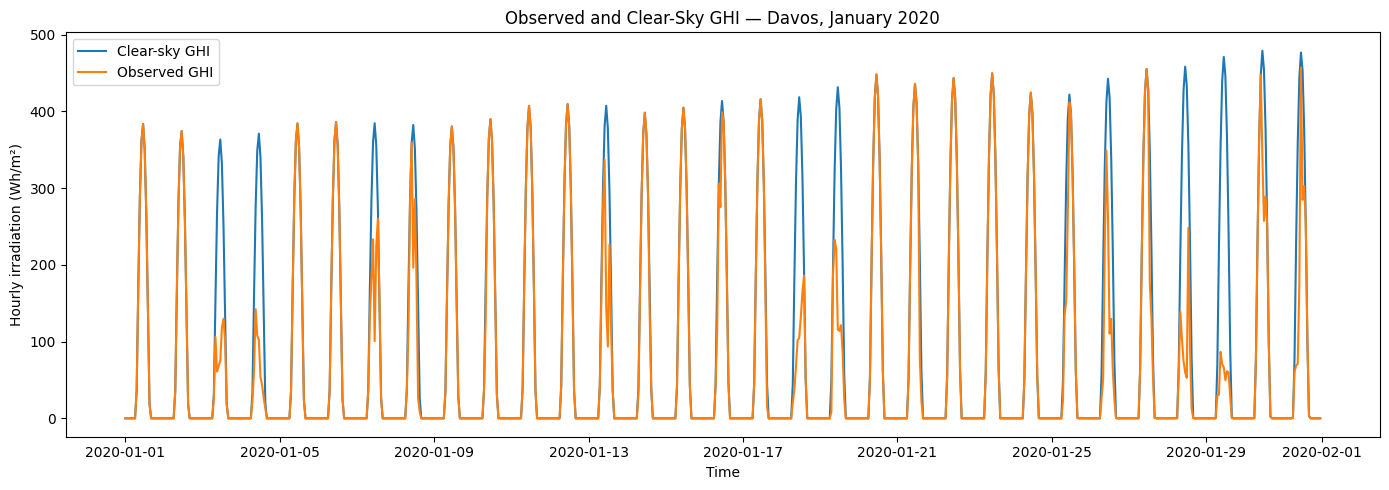

In [14]:
import matplotlib.pyplot as plt

# ==========================================
# OBSERVED VS CLEAR-SKY GHI
# ==========================================

plt.figure(figsize=(14, 5))

plt.plot(
    df["start_time"],
    df["clear_sky_ghi"],
    label="Clear-sky GHI"
)

plt.plot(
    df["start_time"],
    df["ghi"],
    label="Observed GHI"
)

plt.xlabel("Time")
plt.ylabel("Hourly irradiation (Wh/m²)")
plt.title(
    "Observed and Clear-Sky GHI — Davos, January 2020"
)

plt.legend()
plt.tight_layout()
plt.show()

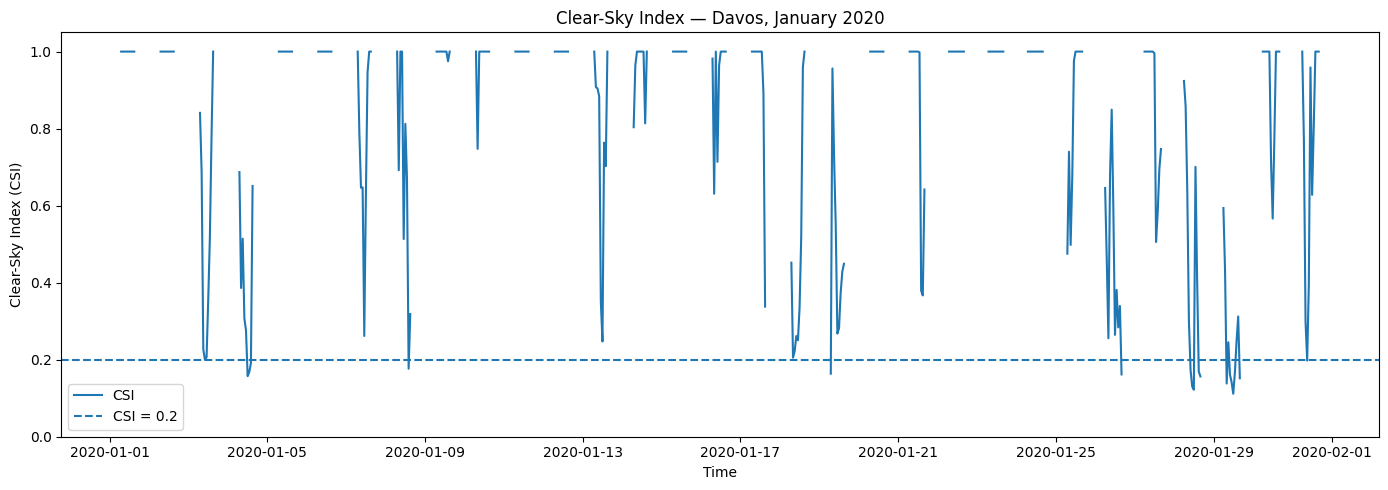

In [15]:
# ==========================================
# CLEAR-SKY INDEX
# ==========================================

plt.figure(figsize=(14, 5))

plt.plot(
    df["start_time"],
    df["csi"],
    label="CSI"
)

plt.axhline(
    0.2,
    linestyle="--",
    label="CSI = 0.2"
)

plt.xlabel("Time")
plt.ylabel("Clear-Sky Index (CSI)")
plt.title(
    "Clear-Sky Index — Davos, January 2020"
)

plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion

This notebook established a clear-sky normalization framework for the CAMS solar-radiation data using the Clear-Sky Index (CSI).

The Clear-Sky Index is defined as:

$$
CSI_t = \frac{GHI_{\text{observed},t}}{GHI_{\text{clear},t}}
$$

where:

- $GHI_{\text{observed},t}$ is the observed global horizontal irradiation during time interval $t$.
- $GHI_{\text{clear},t}$ is the corresponding clear-sky global horizontal irradiation for the same time interval.

The purpose of this normalization is to express the observed solar resource relative to the solar resource that would be expected under the corresponding clear-sky conditions. This reduces the direct influence of the daily and seasonal solar-geometry cycle and provides a normalized measure of solar availability.

### Treatment of nighttime observations

The January 2020 pilot dataset contained 744 hourly observations. Of these, 448 observations had zero clear-sky GHI. These observations correspond to periods where the clear-sky reference itself was zero, so CSI was not calculated for them.

For observations with a positive clear-sky reference, CSI was calculated directly:

$$
CSI_t = \frac{GHI_{\text{observed},t}}{GHI_{\text{clear},t}}
$$

This resulted in 296 valid CSI observations.

### Treatment of very small clear-sky reference values

Some observations had very small but positive clear-sky GHI values, particularly around the transitions between nighttime and daylight.

These observations were not removed solely because their clear-sky reference was small. Instead, they were retained and categorized according to the magnitude of the clear-sky reference.

This approach avoids arbitrarily discarding observations while recognizing that ratios involving very small denominators can be more sensitive to small numerical changes.

The reference categories used in this pilot were diagnostic categories rather than final scientific thresholds.

### CSI validation

The calculated CSI values ranged from 0.1115 to 1.0000.

No valid CSI observations were outside the expected interval:

$$
0 \leq CSI_t \leq 1
$$

for this pilot dataset.

A reconstruction check was also performed. The original observed GHI was reconstructed from the calculated CSI and clear-sky GHI:

$$
GHI_{\text{reconstructed},t}
=
CSI_t \times GHI_{\text{clear},t}
$$

The reconstruction error was then calculated as:

$$
E_t =
GHI_{\text{reconstructed},t}
-
GHI_{\text{observed},t}
$$

The maximum absolute reconstruction error was approximately:

$$
2.84 \times 10^{-14}\ \text{Wh/m}^2
$$

This is effectively zero at the scale of the dataset and is attributable to floating-point numerical precision. Therefore, the CSI calculation is numerically consistent with the original GHI observations.

### Observed versus clear-sky solar availability

The comparison between observed GHI and clear-sky GHI demonstrates that the observed solar resource varies substantially relative to the corresponding clear-sky reference.

When observed GHI is close to clear-sky GHI:

$$
CSI_t \approx 1
$$

the available solar resource is close to the clear-sky reference.

When observed GHI is substantially lower than the clear-sky reference:

$$
CSI_t \ll 1
$$

the available solar resource is strongly reduced relative to the clear-sky expectation.

The CSI time series therefore provides a normalized representation of solar availability that is more suitable for subsequent anomaly analysis than raw GHI alone.

### Low-CSI observations

In the January 2020 pilot, 18 of the 296 valid CSI observations had:

$$
CSI_t < 0.2
$$

corresponding to approximately 6.08% of the valid CSI observations.

These observations represent periods of very low normalized solar availability in the pilot dataset.

However, the value $CSI = 0.2$ is used here only as a descriptive reference for examining the lower tail of the CSI distribution. It is **not** adopted as the final solar-drought threshold.

A drought classification requires a longer historical record from which an appropriate reference distribution, anomaly threshold, and persistence criterion can be established.

### Scientific interpretation and limitations

The January 2020 dataset is used here as a pilot dataset to verify the data-processing and normalization methodology.

The results demonstrate that:

1. The CAMS observations can be separated into nighttime and nonzero-reference periods.
2. CSI can be calculated for observations with a positive clear-sky reference.
3. The calculated CSI values remain within the expected range for this dataset.
4. The CSI calculation can reproduce the original observed GHI to numerical precision.
5. The normalized time series reveals periods of substantially reduced solar availability.
6. Some low-CSI observations occur close together in time, providing motivation for investigating persistence in the subsequent drought-analysis stage.

However, this one-month pilot is not sufficient to establish climatological drought thresholds or drought frequency.

In particular, the pilot dataset cannot by itself determine:

- the statistically normal range of solar availability;
- an appropriate anomaly threshold;
- the rarity of low-CSI conditions;
- the minimum persistence required for a drought event;
- seasonal differences in drought occurrence;
- the frequency, duration, or severity distribution of solar droughts.

These questions require a substantially longer historical record.

### Transition to historical analysis

The next stage of the project will therefore use the longer historical CAMS solar-radiation record.

The planned analytical sequence is:

$$
\text{Historical solar data}
\rightarrow
\text{Quality control}
\rightarrow
\text{Clear-sky normalization}
\rightarrow
\text{CSI climatology}
\rightarrow
\text{Anomaly identification}
\rightarrow
\text{Persistence analysis}
\rightarrow
\text{Solar drought events}
$$

The historical dataset will provide the basis for determining statistically justified thresholds and identifying persistent periods of anomalously low solar availability.

Therefore, the normalization procedure developed in this notebook is considered suitable for proceeding to analysis of the longer historical dataset.